# Themes, Palettes & Fonts

Two figures can plot the *same* data and tell very different stories: one looks
like rough output from a `for` loop, the other like it walked straight out of a
journal, a poster, or a dark conference slide. The difference is **style** — and
in skyplothelper style is a small, composable system you drive with one call,
not a pile of `rcParams` you re-tune for every figure.

This tutorial is the deep dive on that system: how to make everything you draw
look like *yours*, coherently, across a paper, a talk, a web post, or a dark
page. It answers two important questions — **"how do I apply a
coordinated look?"** and **"how do I adjust each part of it?"**

The system has **three composable layers** plus a couple of specialist helpers:

- **base** — the *structure* (ticks, spines, grid, fonts, dpi);
- **theme** — the *page* (background and foreground colors, light vs. dark);
- **palette** — the *data colors* (the cycle applied to your plotted series);
- and, for sky figures and finder charts, **`style_wcs_axes`** and the
  **annotation palettes** that sit alongside the three.

We build from a single knob up to a full house style, one layer at a time.

> **Scope:** this tutorial is about the *whole-figure look* — themes, palettes,
> and fonts applied across everything you draw. Styling a single frame's **own**
> ticks, gridlines, and labels (formats, placement, highlighting) is its
> companion topic — see [Decorating Frames](decorating_frames.ipynb). The dense
> reference for everything here is the
> [Styling & themes](../guide/styling.md) guide page; this is its guided tour.

> **Note — these figures are light-only, by design.** Almost every figure here
> *compares* looks: matplotlib's defaults against successive layers of styling, or
> a light theme beside a dark one. Those comparisons only read if the figure frame
> stays a neutral constant. So — unlike the other tutorials, which ship a dark
> variant for the docs' dark mode — these figures are **not** re-rendered under a
> dark theme: a theme-aware dark pass would recolor the titles and backgrounds the
> comparisons depend on, hiding the very thing each figure is meant to show. They
> stay light in both page modes. (Nothing here forces *your* pages or plots to
> light; it's only how these particular specimens are shown.)

## Contents

1. [The three-layer mental model](#1.-The-three-layer-mental-model)
2. [Base presets](#2.-Base-presets)
3. [Themes](#3.-Themes)
4. [Cycle palettes](#4.-Cycle-palettes)
5. [Annotation palettes](#5.-Annotation-palettes)
6. [Fonts](#6.-Fonts)
7. [Styling sky frames](#7.-Styling-sky-frames)
8. [Building a house style](#8.-Building-a-house-style)
9. [Quick reference](#9.-Quick-reference)
10. [Where to go next](#10.-Where-to-go-next)

In [1]:
import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

import skyplothelper as sph

**A convention for this notebook.** Styling changes matplotlib's *global*
`rcParams`, so a cell that sets a style would otherwise leak that look into every
later cell — and the figures would depend on the order you ran them in. To keep
each example self-contained and re-runnable in any order, every styled figure
below wraps its styling in a **`with sph.style_context(...):`** block, which
applies the look only inside the block and restores the previous settings on
exit. In your own scripts you'll more often call `sph.set_style(...)` **once** at
the top to pin a look for the whole session — both take the exact same keywords.

We also reuse one deliberately boring **demo plot** throughout — a few
spectrum-like series, an error-bar scatter, a legend, and a bit of math in the
axis label — so your attention stays on the *style*, never on the data:

In [2]:
_x = np.linspace(0, 10, 250)


def demo_plot(ax, n=4, grid=True, legend=True, labels=True):
    """A small, style-agnostic data plot reused across the whole notebook.

    Exercises the parts a style actually touches: the color cycle (several
    series), markers + error bars, a legend, a grid, and a math axis label.
    Pass ``labels=False`` in tight multi-panel galleries where a preset's large
    type would crowd a neighbor (the page/colors are the point there, not the
    axis names).
    """
    for i in range(n):
        ax.plot(_x, np.sin(_x * 0.8 + i * 0.7) * (1 - 0.06 * i) + 0.15 * i,
                label=f"series {i + 1}")
    rng = np.random.default_rng(3)
    ax.errorbar(rng.uniform(0.5, 9.5, 9), rng.uniform(-1, 1.4, 9),
                yerr=rng.uniform(0.08, 0.22, 9), fmt="o", ms=4,
                color="0.3", ecolor="0.6", zorder=5)
    if grid:
        ax.grid(True)
    if labels:
        ax.set_xlabel(r"wavelength ($\mu$m)")
        ax.set_ylabel("normalized flux")
    if legend:
        ax.legend(loc="upper right", ncol=2, fontsize="small")
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.6, 2.3)

### The 30-second version

Here is where we're headed. The same demo plot, twice: **bare matplotlib** on the
left, and on the right the result of a **single `set_style` call** that sets the
structure, the data colors, and the font together (we've left the *page* light
here; that's the one more layer — the theme — you'll add for dark figures).
Everything in this tutorial is about taking the left to the right, and bending
each part to taste.

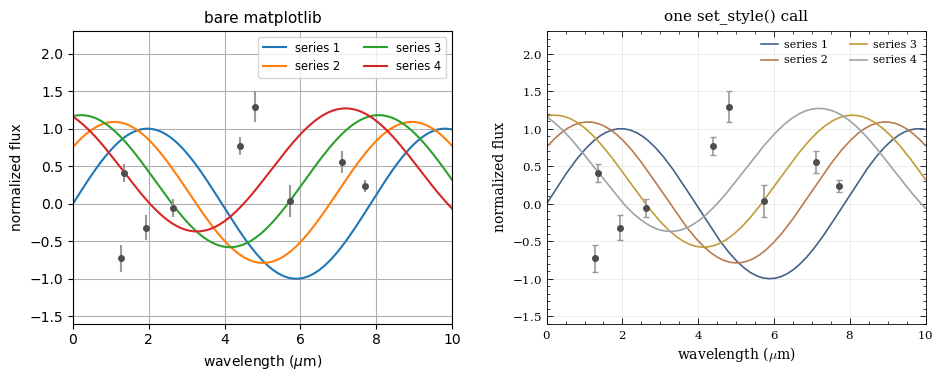

In [3]:
# Pin a clean default for the whole figure (so the bare panel is a true baseline);
# the right panel layers one set_style call on top via a nested context.
with plt.style.context("default"):
    fig = plt.figure(figsize=(11, 3.8))
    ax = fig.add_subplot(1, 2, 1)          # left: untouched matplotlib
    demo_plot(ax)
    ax.set_title("bare matplotlib", fontsize=11)
    with sph.style_context(base="journal", palette="uranometria", font="journal"):
        ax = fig.add_subplot(1, 2, 2)      # right: one call — base+palette+font
        demo_plot(ax)
        ax.set_title("one set_style() call", fontsize=11)
    fig.subplots_adjust(wspace=0.25)
    plt.show()

```python
sph.set_style(base="journal", palette="uranometria", font="journal")
```

That one line is the whole system in miniature. The rest of this tutorial pulls it
apart — what each layer owns, the presets in each, and how to compose your own.

## 1. The three-layer mental model

The whole system rests on one idea: **base, theme, and palette are independent,
and they compose in a fixed order.** Each owns a different category of setting,
so you can change one without disturbing the others — improve the *structure* of
a throwaway inspection plot without touching the colors that encode your sources;
swap the *data palette* and leave the frame alone; or flip the *page* to dark for
a slide and keep everything else.

`sph.set_style(base=…, theme=…, palette=…)` applies all three at once, always in
the order **base → theme → palette → any extra rcParams** — so a later layer wins
on a shared setting. The clearest way to feel what each layer owns is to add them
one at a time to the *same* plot and watch only its category change:

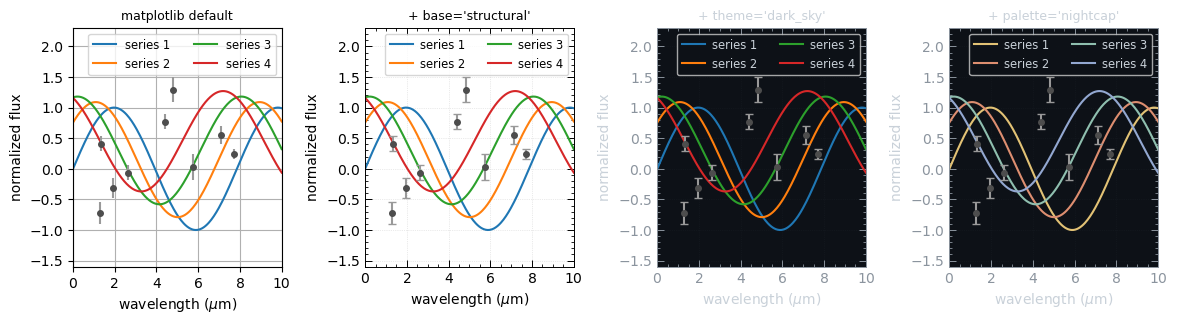

In [4]:
layers = [
    ("matplotlib default", None),
    ("+ base='structural'", dict(base="structural")),
    ("+ theme='dark_sky'", dict(base="structural", theme="dark_sky")),
    ("+ palette='nightcap'",
     dict(base="structural", theme="dark_sky", palette="nightcap")),
]

# Pin a clean matplotlib default as the shared starting point for the whole
# buildup — so panel 1 is a true baseline and each later panel layers ONLY what
# its title names on top of that same start. (It also makes the diagram render
# the same no matter what style happens to be active when the cell runs.)
with plt.style.context("default"):
    fig = plt.figure(figsize=(14, 3.1))
    for i, (title, cfg) in enumerate(layers, start=1):
        if cfg is None:
            ax = fig.add_subplot(1, 4, i)
            demo_plot(ax)
        else:
            with sph.style_context(base=cfg["base"], theme=cfg.get("theme"),
                                   palette=cfg.get("palette")):
                ax = fig.add_subplot(1, 4, i)
                demo_plot(ax)
        ax.set_title(title, fontsize=9)
    fig.subplots_adjust(wspace=0.4)
    plt.show()

Read left to right, each step changes exactly one category:

| Layer | What it owns | In the panels above |
| --- | --- | --- |
| **base** | structure: tick direction/length, spine & line weights, grid, fonts, dpi | panel 2 — ticks turn inward, the frame lightens, the grid recedes; **colors unchanged** |
| **theme** | the page: background + foreground colors, light vs. dark | panel 3 — the canvas goes dark and the text/ticks invert; **data colors still unchanged** |
| **palette** | the data colors: the cycle applied to your series | panel 4 — only now do the line colors change |

That `'structural'` base is special: it's the one preset that **deliberately
leaves your colors and fonts untouched** (panels 1 and 2 share the exact same
line colors and font), nudging only the structure. It's the "improve the
defaults but keep my encoding" choice. Every *other* base preset also seeds a
default color cycle at the base step — but the **palette** layer is applied after
base, so an explicit `palette=` always wins.

> **Note:** a skyplothelper **theme** never silently recolors your data — the
> built-in themes set only page and foreground colors, so switching to a dark
> theme keeps whatever palette you chose. (The one exception, covered in
> [Section 3](#3.-Themes), is borrowing a *matplotlib* built-in theme like
> `'ggplot'`, which carries its own cycle.)

Each layer also has a **standalone setter** — `set_base_style`, `set_theme`,
`set_palette` — for when you only ever touch one category. The sections below
take the three layers in turn, then add the sky-frame and annotation helpers.

## 2. Base presets

The **base** layer is the structure: tick direction and length, spine and line
weights, the grid, fonts, and output dpi — the "line-weight hierarchy and
chart-junk removal" that separates a polished figure from untouched matplotlib.
skyplothelper ships eight base presets, each tuned for a medium. The registry is
`sph.BASE_PRESETS`; here is every one on the same demo plot.

> **Tip:** loop over the registry rather than hard-coding names — a gallery built
> this way picks up any preset added to the package automatically.

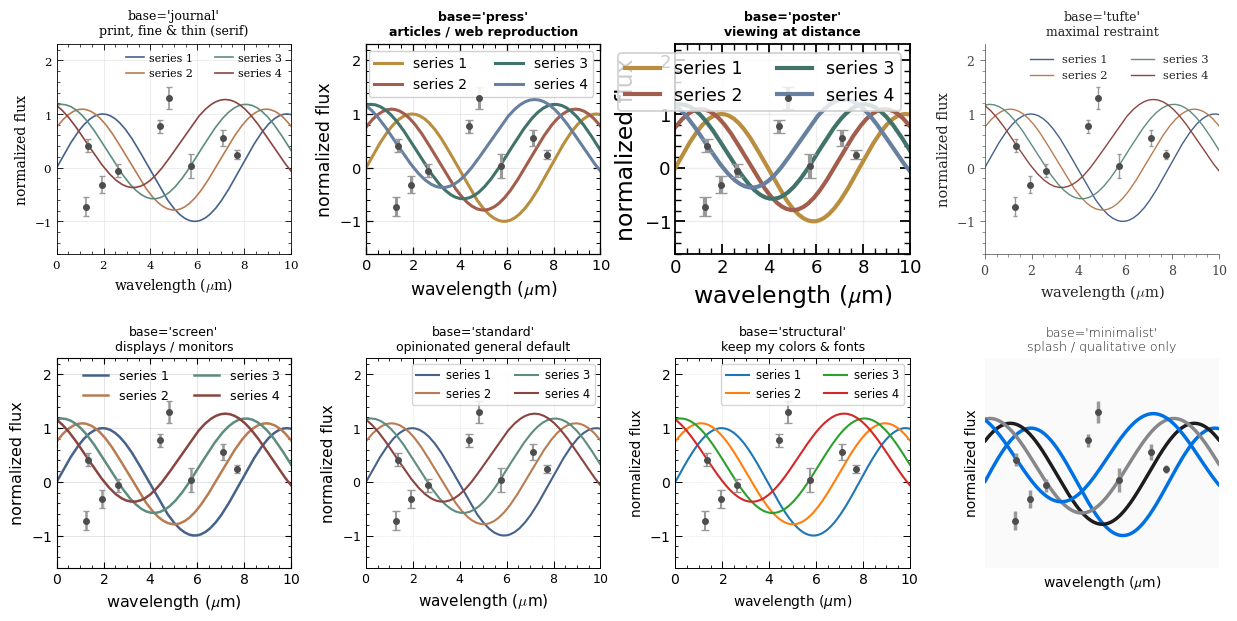

In [5]:
# Render every base preset on the identical demo plot. structural/standard are the
# two everyday entry points; the rest target a medium (print, web, distance, …).
preset_notes = {
    "standard": "opinionated general default",
    "structural": "keep my colors & fonts",
    "journal": "print, fine & thin (serif)",
    "press": "articles / web reproduction",
    "poster": "viewing at distance",
    "tufte": "maximal restraint",
    "screen": "displays / monitors",
    "minimalist": "splash / qualitative only",
}
names = list(sph.BASE_PRESETS)
ncol = 4
nrow = -(-len(names) // ncol)
fig = plt.figure(figsize=(15, 3.4 * nrow))
for i, name in enumerate(names, start=1):
    # Each panel pins a clean default first, then applies only this one base, so
    # the panels don't bleed structure into one another.
    with plt.style.context("default"), sph.style_context(base=name):
        ax = fig.add_subplot(nrow, ncol, i)
        demo_plot(ax, grid=(name not in ("tufte", "minimalist")),
                  legend=(name != "minimalist"))
        ax.set_title(f"base='{name}'\n{preset_notes.get(name, '')}", fontsize=9)
fig.subplots_adjust(wspace=0.32, hspace=0.5)
plt.show()

A few are worth calling out:

- **`standard`** is the opinionated everyday default — a refined look with a
  serif font and the `uranometria` cycle. **`structural`** is its restrained
  sibling: the *same* structural nudges but **no colors or fonts**, for when you
  want better defaults without overriding an encoding you've set yourself.
- **`journal`** goes thin, fine, and serif at high dpi for print; **`press`**
  and **`poster`** go larger, bolder, and sans for reproduction and for reading
  at distance; **`screen`** sits in between, weighted so hairlines survive a
  monitor; **`tufte`** strips to hairline spines and no grid.

`minimalist` deserves a note of its own.

### Knowing when to reach for `minimalist`

`minimalist` is an Apple-keynote / product-reveal look — frameless, no ticks, no
tick labels, a light-weight near-monochrome cycle — built for **splash and title
images**: a lone globe render, a single FITS cutout, a figure that functions as a
logo. The thing it strips is exactly the scaffolding you need to **read values off
a plot**, so the one place it fails is a figure whose job is *quantitative
readout*. Side by side — the same scatter where the axes have been stripped away
(left), and the kind of hero image it's *actually* for (right):

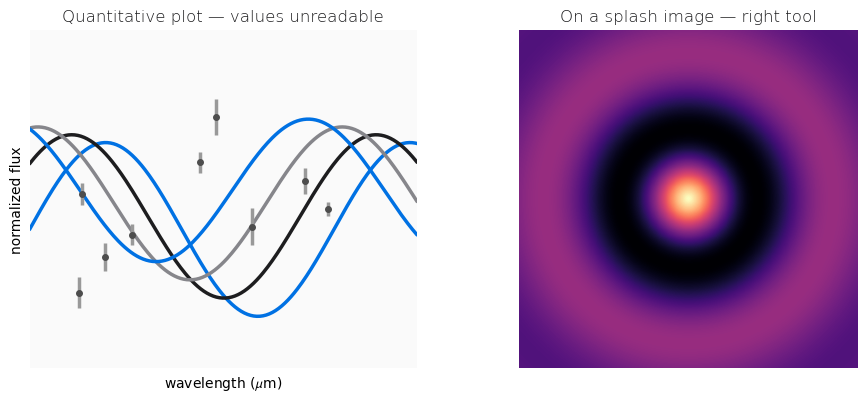

In [6]:
fig = plt.figure(figsize=(11, 4.4))

# Left: minimalist on a real data plot — frameless + tickless + no labels means
# there's nothing to read the values against (grid off too, so it's truly bare).
# Override the preset's huge splash-title size so the two panel titles don't collide.
with plt.style.context("default"), sph.style_context(base="minimalist"):
    ax = fig.add_subplot(1, 2, 1)
    demo_plot(ax, grid=False, legend=False)
    ax.set_title("Quantitative plot — values unreadable", fontsize=12)

# Right: minimalist on a splash image — frameless is exactly right here. (No
# cmap= needed: the preset sets the image colormap too.)
with plt.style.context("default"), sph.style_context(base="minimalist"):
    ax = fig.add_subplot(1, 2, 2)
    grid = np.linspace(-1.4, 1.4, 300)
    X, Y = np.meshgrid(grid, grid)
    R = np.hypot(X, Y)
    ax.imshow(np.cos(R * 5) * np.exp(-R * 1.4), extent=[-1.4, 1.4, -1.4, 1.4])
    ax.set_aspect("equal")
    ax.set_title("On a splash image — right tool", fontsize=12)
fig.subplots_adjust(wspace=0.2)
plt.show()

The nuance worth keeping: the left isn't "minimalist is bad for data" — it's
"minimalist is bad when the reader must *measure* the data." If the plot is
**purely qualitative** — the *shape*, *trend*, or *comparison* is the entire
message and no one needs to read a number off the axes (a talk slide showing
"this rises, then falls", a schematic of a relationship) — then minimalist's
stripped, clean look is an asset, not a liability. The test is the **job of the
figure**, not whether the underlying numbers are quantitative: reach for
`minimalist` for splash images and qualitative storytelling, and reach past it
the moment a reader needs the axes to read values.

> **Note:** `minimalist` sets `font.weight='light'`, and DejaVu (matplotlib's
> only guaranteed font) has no light face. On a machine with no light-weight
> sans installed you may see a missing-glyph warning on prime/double-prime
> symbols (′ ″) in sky coordinate labels — a pure font-availability issue, not a
> bug. It's a non-issue for the figures `minimalist` is meant for (a splash image
> or a qualitative slide carries no sexagesimal coordinate labels).

**Mix and match.** A preset is a starting point, not a straitjacket: any extra
`rcParams` you pass land **last**, overriding that one setting while keeping the
rest of the preset. So you can take `journal` but turn its grid back off, or
bump a line width, without rebuilding the dict. (And if you want a fully custom
base rather than tweaks on a preset, `base=` also accepts a complete rcParams
dict of your own — the same goes for `theme=`.)

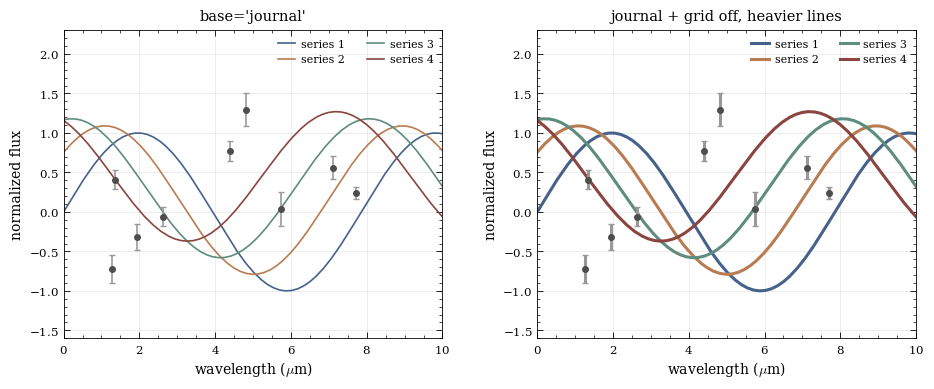

In [7]:
fig = plt.figure(figsize=(11, 4.0))
with plt.style.context("default"), sph.style_context(base="journal"):
    ax = fig.add_subplot(1, 2, 1)
    demo_plot(ax)
    ax.set_title("base='journal'")
# Same preset, two rcParams overridden last — grid off, heavier data lines.
with plt.style.context("default"), sph.style_context(
        base="journal", **{"axes.grid": False, "lines.linewidth": 2.2}):
    ax = fig.add_subplot(1, 2, 2)
    demo_plot(ax)
    ax.set_title("journal + grid off, heavier lines")
fig.subplots_adjust(wspace=0.25)
plt.show()

## 3. Themes

Where **base** sets the structure, a **theme** sets the *page*: the figure and
axes background, the foreground (text, ticks, spine), and the grid/label colors
that go with them — coordinated for light or dark. A theme is what takes a figure
from a white journal page to a dark conference slide. skyplothelper ships four:
`'publication'` and `'poster'` (light), `'twilight'` and `'dark_sky'` (dark). The
same demo plot under each:

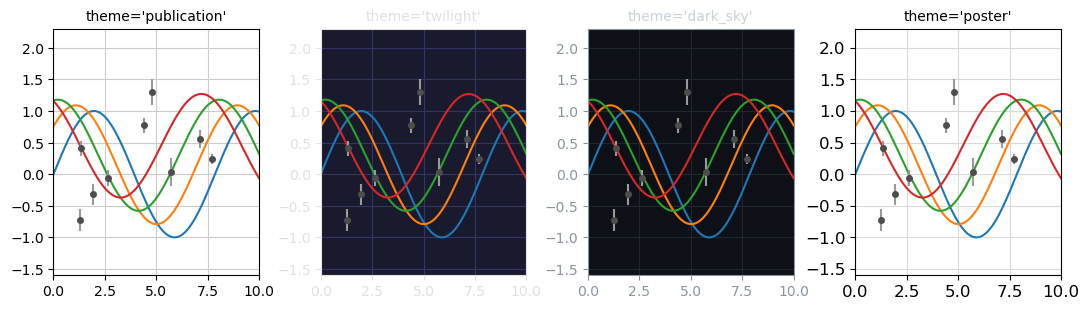

In [8]:
themes = ["publication", "twilight", "dark_sky", "poster"]
fig = plt.figure(figsize=(13, 3.2))
for i, theme in enumerate(themes, start=1):
    # Pin a clean default first, then add ONLY the theme — no base, no palette — so
    # every panel starts from the same data colors and only the page changes.
    with plt.style.context("default"), sph.style_context(theme=theme):
        ax = fig.add_subplot(1, 4, i)
        demo_plot(ax, legend=False, labels=False)
        ax.set_title(f"theme='{theme}'", fontsize=10)
fig.subplots_adjust(wspace=0.3)
plt.show()

Notice the **data colors are identical** across all four panels — the default
matplotlib cycle, untouched. That's the deliberate rule: a skyplothelper theme
recolors the page *around* your data, never the data itself, so flipping to a dark
theme for a talk never surprises you with new series colors. You choose data
colors separately, with the **palette** layer ([Section 4](#4.-Cycle-palettes)).

> **Note:** yes, there is both a `poster` **base** and a `poster` **theme** —
> same name, different layers. `base='poster'` is the big-type, heavy-line
> *structure* for reading at distance; `theme='poster'` is a matching
> high-contrast light *page*. They pair naturally
> (`set_style(base="poster", theme="poster")`) but work independently.

**The one exception: borrowed matplotlib themes.** `set_theme` also accepts any
matplotlib built-in style name (`'ggplot'`, `'bmh'`, `'seaborn-v0_8'`, …). Those
are full styles that *do* carry their own color cycle, so they **will** restyle
your series. Here the same palette (`'atlas'`) survives a skyplothelper dark theme
(left) but is overridden by `ggplot`'s built-in cycle (right):

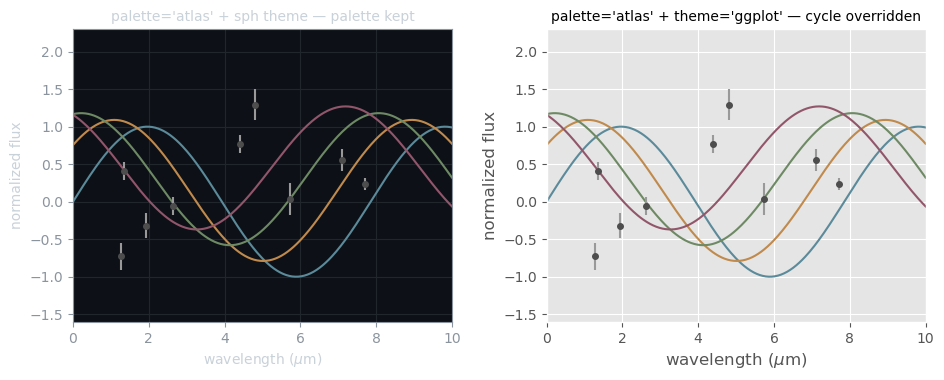

In [9]:
fig = plt.figure(figsize=(11, 3.8))
# Left: an sph theme leaves the chosen palette alone.
with plt.style.context("default"), sph.style_context(theme="dark_sky",
                                                     palette="atlas"):
    ax = fig.add_subplot(1, 2, 1)
    demo_plot(ax, legend=False)
    ax.set_title("palette='atlas' + sph theme — palette kept", fontsize=10)
# Right: a matplotlib built-in carries its own cycle, overriding the palette.
with plt.style.context("default"), sph.style_context(theme="ggplot",
                                                     palette="atlas"):
    ax = fig.add_subplot(1, 2, 2)
    demo_plot(ax, legend=False)
    ax.set_title("palette='atlas' + theme='ggplot' — cycle overridden", fontsize=10)
fig.subplots_adjust(wspace=0.25)
plt.show()

> **Note:** to keep your palette while borrowing a matplotlib style, pass the
> `palette=` *after* the theme (as above) — `set_style` applies palette last, so
> re-asserting it restores your colors over the borrowed cycle.

**Light and dark from one palette.** Because a theme only touches the page, a
*dual-mode* palette holds its data colors steady on either background. Here
`'uranometria'` reads cleanly on a light page and a dark one — same colors, no
adjustment:

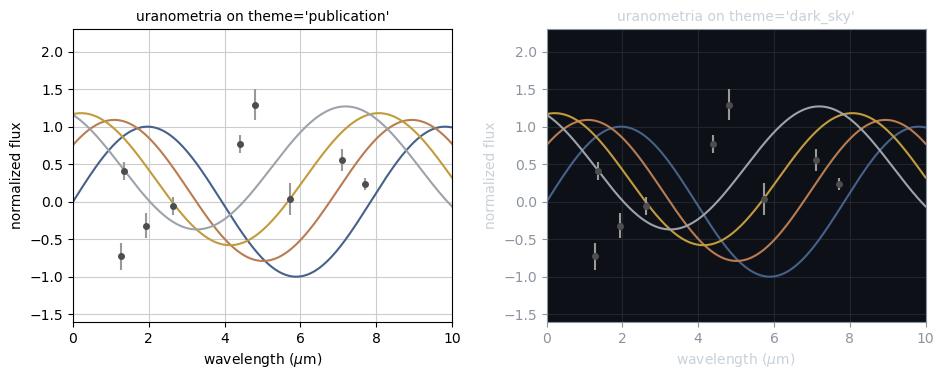

In [10]:
fig = plt.figure(figsize=(11, 3.8))
for i, theme in enumerate(["publication", "dark_sky"], start=1):
    with plt.style.context("default"), sph.style_context(theme=theme,
                                                         palette="uranometria"):
        ax = fig.add_subplot(1, 2, i)
        demo_plot(ax, legend=False)
        ax.set_title(f"uranometria on theme='{theme}'", fontsize=10)
fig.subplots_adjust(wspace=0.25)
plt.show()

### What inherits the theme, and what doesn't

A theme sets foreground colors, so it's natural to assume anything you *don't*
color explicitly will follow it. That holds for **text** — and, importantly, not
for much else. matplotlib resolves an unset color differently for each kind of
artist, and the difference is worth knowing before you draw your own annotations
on a dark figure:

| If you draw… | with no color set, you get | follows… |
| --- | --- | --- |
| `ax.text` / `ax.annotate` | `rcParams['text.color']` — light on a dark theme | the **theme** |
| `ax.plot` / `ax.scatter` | the next color in the cycle | the **palette** (by design) |
| a `Line2D(...)` you build by hand | `rcParams['lines.color']`, which is `'C0'` — the cycle's *first* color, pinned | the **palette**, but never advancing |

The middle row is the rule from earlier in this section doing its job: your
*data* keeps the colors you chose, on whatever page it lands. The row to watch is
the last one — an artist you construct yourself and add to the axes takes `'C0'`
forever, so it neither follows a dark theme nor advances with the cycle, and a
series of them all come out the same color.

The practical rule: **for decoration you draw yourself, set the color explicitly**
— from a cycle palette for data, or from an annotation palette
([Section 5](#5.-Annotation-palettes)) for scaffolding — rather than relying on
the default to "do the theme thing."

That dual-mode behavior isn't automatic for *every* palette — some are tuned for
a light page, some for dark. The next section is all about choosing the data
colors, and reading each palette's intended mode.

## 4. Cycle palettes

The **palette** layer sets your *data colors* — the cycle matplotlib walks as you
plot successive series. skyplothelper ships six, in `sph.CYCLE_PALETTES`, each
tuned to stay distinct under **color-vision deficiency** *and* in grayscale (more
on that below). Each carries a `mode`: `dual` (reads on a light *or* dark page),
`light`-only, or `dark`-only. All six at a glance:

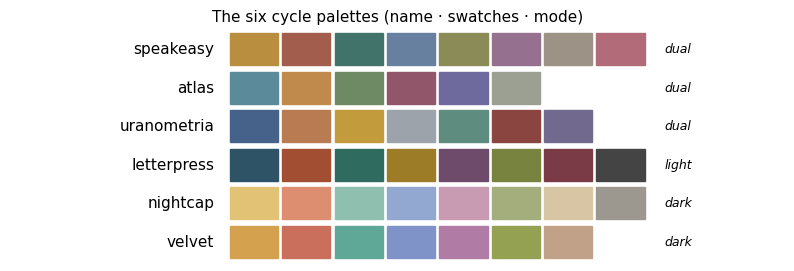

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.0))
pal_names = list(sph.CYCLE_PALETTES)
ncolors = max(len(sph.CYCLE_PALETTES[n]["colors"]) for n in pal_names)
for r, name in enumerate(pal_names):
    spec = sph.CYCLE_PALETTES[name]
    y = len(pal_names) - 1 - r                       # first palette on top
    for c, color in enumerate(spec["colors"]):
        ax.add_patch(plt.Rectangle((c, y + 0.08), 0.92, 0.84, color=color))
    ax.text(-0.3, y + 0.5, name, ha="right", va="center", fontsize=11)
    ax.text(ncolors + 0.3, y + 0.5, spec["mode"], ha="left", va="center",
            fontsize=9, style="italic")
ax.set_xlim(-4.2, ncolors + 2.6)
ax.set_ylim(0, len(pal_names))
ax.axis("off")
ax.set_title("The six cycle palettes (name · swatches · mode)", fontsize=11)
plt.show()

Apply one with `palette='name'` on any styling call, or with the standalone
`sph.set_palette('name')`. A good cycle has to work in more than one role, so
it's worth seeing a palette as **swatches**, as **plot lines**, and as the
semi-transparent **region fills** you'd use for overlapping footprints or
confidence bands. `'uranometria'`, all three ways:

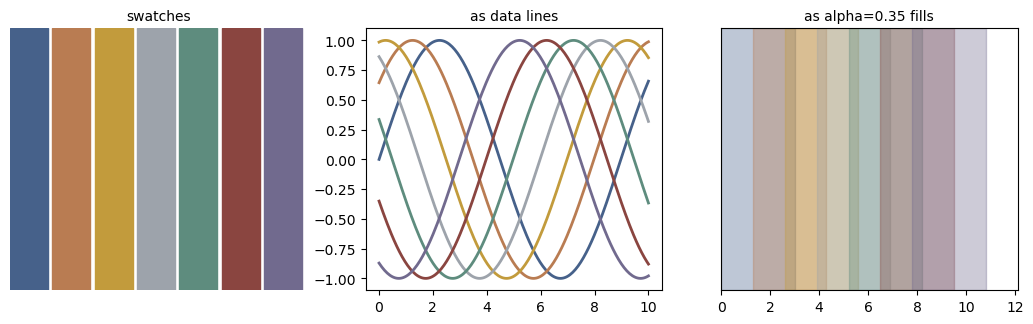

In [12]:
colors = sph.CYCLE_PALETTES["uranometria"]["colors"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# Swatches.
for c, color in enumerate(colors):
    axes[0].add_patch(plt.Rectangle((c, 0), 0.9, 1, color=color))
axes[0].set_xlim(0, len(colors))
axes[0].set_ylim(0, 1)
axes[0].axis("off")
axes[0].set_title("swatches", fontsize=10)

# As plot lines.
xx = np.linspace(0, 10, 200)
for i, color in enumerate(colors):
    axes[1].plot(xx, np.sin(xx * 0.7 + i * 0.7), color=color, lw=2)
axes[1].set_title("as data lines", fontsize=10)

# As alpha=0.35 region fills (the overlapping-footprint / band case).
for i, color in enumerate(colors):
    center = i * 1.3
    axes[2].axvspan(center, center + 3.0, color=color, alpha=0.35)
axes[2].set_xlim(0, len(colors) * 1.3 + 3)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_title("as alpha=0.35 fills", fontsize=10)
fig.subplots_adjust(wspace=0.2)
plt.show()

### Reading the mode — light, dark, and dual

A palette's `mode` tells you which page it was tuned for. A **dual** palette
(`'speakeasy'`) is balanced to read on either background; a **light**-only one
(`'letterpress'`) uses dark inks that vanish on a dark page, and a **dark**-only
one (`'nightcap'`) uses bright tints that wash out on white. Same three palettes,
each shown on the background it suits and the one it doesn't:

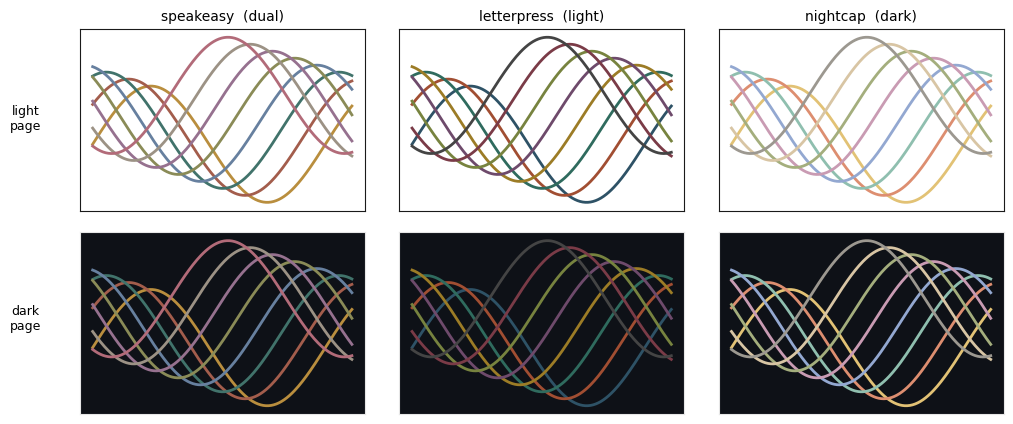

In [13]:
demo = [("speakeasy", "dual"), ("letterpress", "light"), ("nightcap", "dark")]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.0))
xx = np.linspace(0, 10, 200)
for col, (name, mode) in enumerate(demo):
    cols = sph.CYCLE_PALETTES[name]["colors"]
    # Each column's panels simulate the two destinations: a white page, and a
    # typical dark-slide/web tone (with a matching light spine).
    for row, (bg, fg) in enumerate([("white", "0.1"), ("#0E1117", "0.9")]):
        ax = axes[row, col]
        ax.set_facecolor(bg)
        for i, color in enumerate(cols):
            ax.plot(xx, np.sin(xx * 0.7 + i * 0.6) + 0.12 * i, color=color, lw=2)
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(fg)
        if row == 0:
            ax.set_title(f"{name}  ({mode})", fontsize=10)
fig.text(0.085, 0.70, "light\npage", ha="center", va="center", fontsize=9)
fig.text(0.085, 0.30, "dark\npage", ha="center", va="center", fontsize=9)
fig.subplots_adjust(wspace=0.12, hspace=0.12, left=0.13)
plt.show()

Read down each column: `speakeasy` holds up top and bottom; `letterpress`'s dark
inks disappear on the dark page; `nightcap`'s bright tints wash out on white. Pick
a `dual` palette when you don't know where a figure will end up, or a mode-matched
one when you do. (The default look uses `uranometria`, a `dual` palette, for
exactly this reason.)

### Distinct for everyone — color vision and grayscale

The palettes are tuned so the colors stay **distinguishable under color-vision
deficiency** and **in grayscale** — the difference between a figure that
communicates to every reader and one that collapses to mush for the ~8% of men
with red–green CVD or anyone reading a black-and-white printout. We can *check*
this rigorously by running a palette through a CVD simulation. Here `'atlas'`
under normal vision, simulated deuteranopia and protanopia (the two common
red–green types), and desaturated to grayscale:

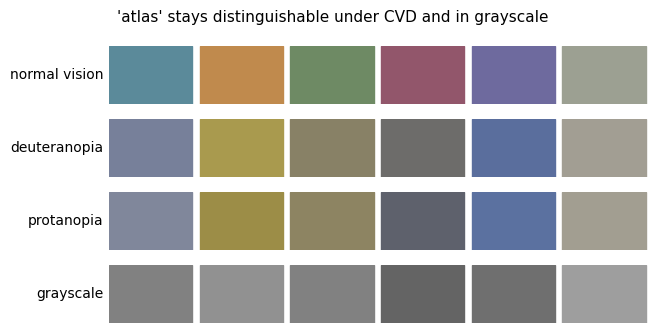

In [14]:
from colorspacious import cspace_convert  # noqa: E402


def simulate_cvd(rgb, cvd_type, severity=100):
    """Simulate how an RGB array (N,3) looks under a given CVD type."""
    space = {"name": "sRGB1+CVD", "cvd_type": cvd_type, "severity": severity}
    return np.clip(cspace_convert(rgb, space, "sRGB1"), 0, 1)


def to_gray(rgb):
    """Perceptual-luminance grayscale of an RGB array (N,3)."""
    lum = rgb @ np.array([0.2126, 0.7152, 0.0722])
    return np.repeat(lum[:, None], 3, axis=1)


atlas = np.array([mpl.colors.to_rgb(c)
                  for c in sph.CYCLE_PALETTES["atlas"]["colors"]])
views = [("normal vision", atlas),
         ("deuteranopia", simulate_cvd(atlas, "deuteranomaly")),
         ("protanopia", simulate_cvd(atlas, "protanomaly")),
         ("grayscale", to_gray(atlas))]

fig, axes = plt.subplots(len(views), 1, figsize=(8, 3.6))
for ax, (label, cols) in zip(axes, views):
    for c, color in enumerate(cols):
        ax.add_patch(plt.Rectangle((c, 0), 0.92, 1, color=color))
    ax.set_xlim(0, len(cols))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("'atlas' stays distinguishable under CVD and in grayscale", fontsize=11)
fig.subplots_adjust(hspace=0.25, left=0.22)
plt.show()

The swatches stay separable in every row — no two collapse into the same tone.
That's a property worth checking whenever you build a *custom* palette: pass a
list of colors to `palette=` (or `set_palette([...])`) and run it through the same
`simulate_cvd` before trusting it for a figure that matters.

> **Tip:** `palette=` is a pure data-color layer — you can drop it onto an
> otherwise unstyled figure (`with sph.style_context(palette='velvet'):`) to
> recolor *only* the series and leave matplotlib's default structure and page
> exactly as they are.

### A quick note on image colormaps

A cycle palette colors *series* — points and lines. Its counterpart for **raster
/ image data** is a matplotlib **colormap**, and skyplothelper bundles a curated
set of those too. They're a different tool for a different job (coloring a 2-D
intensity map, not the figure's series or its scaffolding), so this is just a
signpost — the full treatment, applying them to real FITS images alongside
stretches, colorbars, and contours, lives in
[FITS Images & Quicklook](fits_images.ipynb).

`sph.show_colormaps()` draws the whole bundled set at a glance:

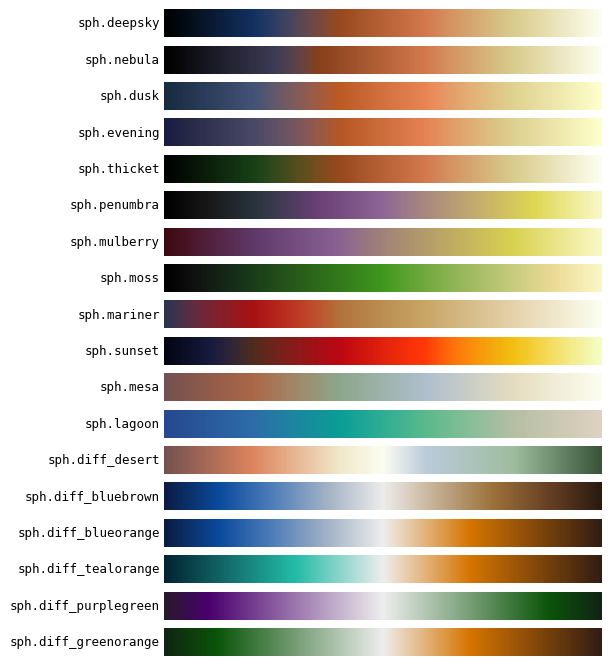

In [15]:
sph.show_colormaps()
plt.show()

Two families: the **sequential** maps (`sph.deepsky` … `sph.lagoon`) run
monotonically dark-to-light for intensity images, while the **diverging**
`sph.diff_*` maps have a neutral center for *signed* data — residuals, difference
maps, velocity fields. Using one is a one-liner anywhere matplotlib takes a
`cmap`:

```python
ax.imshow(data,  cmap="sph.deepsky")           # by registered name
ax.imshow(resid, cmap="sph.diff_blueorange")   # diverging, for +/- data
ax.imshow(data,  cmap="sph.sunset_r")          # _r reverses any map
cmap = sph.get_colormap("sph.nebula")          # grab the Colormap object
sph.list_colormaps()                           # discover the full set
```

> **Note:** these are a *curated, bundled* set (ready-to-use lookup tables), not a
> colormap-authoring kit — reach for a monotonic-luminance sequential map for
> intensity and a `diff_*` map for anything centered on zero. Choosing and
> applying them on real science images is the subject of
> [FITS Images & Quicklook](fits_images.ipynb).

## 5. Annotation palettes

The three layers so far color your *data* and the *page*. Finder charts and star
atlases need something more: a coordinated set of colors for the figure's
**scaffolding** — the star markers, the target ring, two tiers of text, the
compass, the grid, the frame. That's a separate, fourth layer: the **annotation
palettes** in `sph.ANNOTATION_PALETTES`, applied with `style_annotation`.

Unlike a cycle palette (a flat list of data colors), an annotation palette is a
**dict keyed by role** — `stars`, `accent`, `label`, `compass`, and so on. One
call styles the frame, background, and grid *and* hands you the dict so you can
color the elements you draw yourself in the same scheme. The five presets
(`parchment`, `publication`, `dark`, `night`, `denim`) on the same mock finder
chart — the *same code*, five identities:

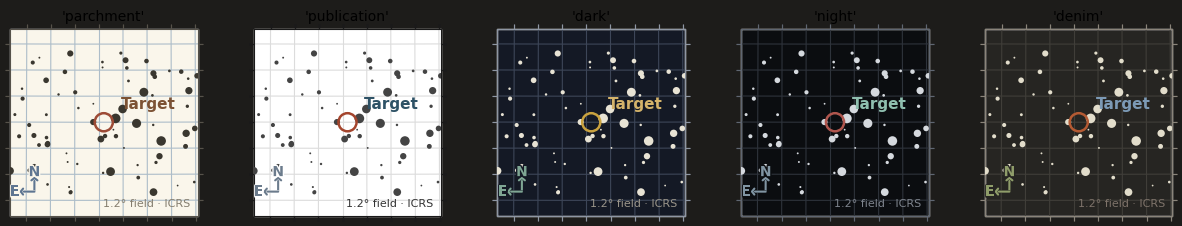

In [16]:
# A small synthetic star field used for the finder-chart demos.
FCEN = (83.8, 22.0)                              # a field near the Crab
_fr = np.random.default_rng(5)
_fn = 70
fra = FCEN[0] + _fr.uniform(-0.6, 0.6, _fn) / np.cos(np.radians(FCEN[1]))
fdec = FCEN[1] + _fr.uniform(-0.45, 0.45, _fn)
fsz = 10 ** _fr.uniform(0.2, 1.7, _fn)


def finder(ax, pal_name, show_coords=True):
    """Draw one mock finder chart, styled by an annotation palette.

    `style_annotation` colors the frame/background/grid AND returns the role
    dict; we pull `stars`/`accent`/`label`/`text2`/`compass` from it so every
    element we draw ourselves stays in the same scheme. Pass ``show_coords=False``
    in a tight side-by-side gallery, where neighboring panels' edge coordinate
    labels would collide (the color identity is the point there, not the coords).
    """
    pal = sph.style_annotation(ax, pal_name)
    if not show_coords:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
    tr = ax.get_transform("world")
    ax.scatter(fra, fdec, transform=tr, s=fsz, c=pal["stars"],
               edgecolors="none", zorder=4)
    # Target: an accent ring + the primary object label in the label color.
    ax.scatter([FCEN[0]], [FCEN[1]], transform=tr, s=170, facecolors="none",
               edgecolors=pal["accent"], linewidths=1.8, zorder=5)
    ax.annotate("Target", xy=FCEN, xycoords=tr, xytext=(12, 10),
                textcoords="offset points", color=pal["label"], fontsize=11,
                fontweight="bold", zorder=7)
    # A secondary caption in the lower-tier text color, and a compass rose.
    ax.text(0.96, 0.05, "1.2° field · ICRS", transform=ax.transAxes,
            color=pal["text2"], fontsize=8, ha="right", zorder=7)
    sph.add_compass(ax, color=pal["compass"], stroke_color=pal["ax_bg"])
    return pal


fig = plt.figure(figsize=(15, 3.3))
for i, name in enumerate(sph.ANNOTATION_PALETTES, start=1):
    ax = sph.make_wcs_frame((1, 5, i), "TAN", center=FCEN, fov_deg=1.2, fig=fig)
    finder(ax, name, show_coords=False)
    ax.set_title(f"'{name}'", fontsize=10)
fig.subplots_adjust(wspace=0.3)
plt.show()

`parchment` and `publication` are light (for a paper or a printed chart);
`dark`, `night`, and `denim` are dark (for a screen or a slide). The idiom is
always the same — capture the returned dict and reuse its roles:

```python
pal = sph.style_annotation(ax, "night")        # styles scaffolding, returns colors
ax.scatter(ra, dec, c=pal["stars"], transform=ax.get_transform("world"))
ax.scatter(ra0, dec0, edgecolors=pal["accent"], facecolors="none")  # target ring
```

### The roles, on one chart

An annotation palette carries **twelve roles**. Here they are in situ on a single
`night`-styled chart, with callouts on the ones that aren't obvious:

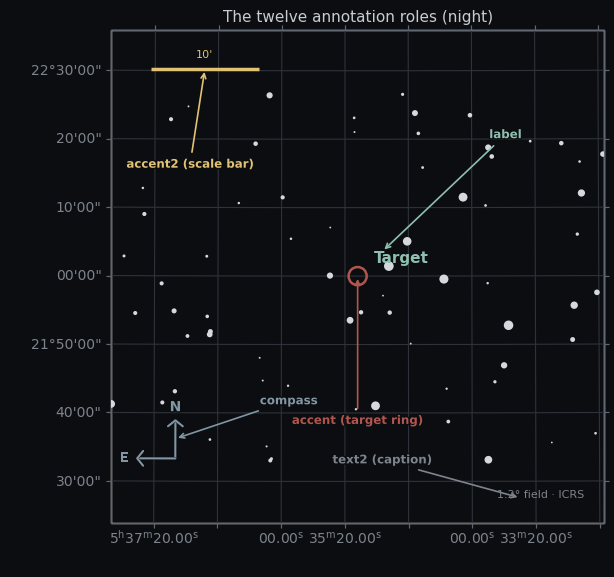

In [17]:
fig = plt.figure(figsize=(8.5, 6.4))
ax = sph.make_wcs_frame(111, "TAN", center=FCEN, fov_deg=1.2, fig=fig)
pal = finder(ax, "night")
# A second accent: a short scale-bar-like mark in accent2.
ax.plot([0.08, 0.30], [0.92, 0.92], transform=ax.transAxes,
        color=pal["accent2"], lw=2.5, solid_capstyle="butt", zorder=7)
ax.text(0.19, 0.94, "10'", transform=ax.transAxes, color=pal["accent2"],
        fontsize=8, ha="center", va="bottom", zorder=7)

# Callout arrows for the roles that are easy to miss. A stroke keeps the callout
# text legible over either the dark field or a bright star.
cstroke = [pe.withStroke(linewidth=2.0, foreground=pal["ax_bg"])]


def callout(text, xy, xytext, color):
    ax.annotate(text, xy=xy, xycoords="axes fraction", xytext=xytext,
                textcoords="axes fraction", color=color, fontsize=8.5,
                fontweight="bold", ha="center", path_effects=cstroke, zorder=8,
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2))


callout("accent (target ring)", (0.5, 0.5), (0.5, 0.20), pal["accent"])
callout("accent2 (scale bar)", (0.19, 0.92), (0.16, 0.72), pal["accent2"])
callout("label", (0.55, 0.55), (0.80, 0.78), pal["label"])
callout("compass", (0.13, 0.17), (0.36, 0.24), pal["compass"])   # rose sits lower-left
callout("text2 (caption)", (0.83, 0.05), (0.55, 0.12), pal["text2"])
ax.set_title("The twelve annotation roles (night)", color=pal["text"], fontsize=11)
plt.show()

The full role key — every annotation palette defines all twelve, so switching
presets recolors the entire kit at once:

| Role | Colors | Role | Colors |
| --- | --- | --- | --- |
| `fig_bg` | the figure background | `compass` | the compass rose |
| `ax_bg` | the axes (sky) background | `grid` | the primary graticule |
| `frame` | the frame / spine | `grid2` | a second graticule (overlay) |
| `text` | primary text (titles) | `stars` | star / source markers |
| `text2` | secondary text (captions) | `accent` | the main highlight (target ring) |
| `label` | object labels | `accent2` | a secondary highlight (scale bar, ruler) |

> **Note:** an annotation palette is *independent* of the cycle palette and
> theme — it's specifically for decoration on a sky frame. You can pair any of
> the three look-layers with any annotation palette; just match light scaffolding
> to a light page and dark to dark. Drawing the overlays themselves (compass,
> scale bars, reticles, second grids) is the subject of their own tutorials —
> here we only borrow them to exercise the roles.

## 6. Fonts

Typography sets the *feel* of a figure as much as color does — but it comes with
a potential trap. **matplotlib does not embed system fonts the way LaTeX does.** Ask for a
family that isn't installed and matplotlib silently falls back (usually to DejaVu)
and emits a warning that's easy to miss in a notebook. A figure that looks perfect
on your machine can quietly degrade on a co-author's. So the real question is never
"what's the prettiest font" but "what's the prettiest font *that will still be
there* when the final figure is rendered." Three reliable tiers answer it:

| Tier | What | Examples | When |
| --- | --- | --- | --- |
| **1 — bundled** | ships with matplotlib, always present | DejaVu Serif/Sans/Mono; the `cm`/`stix` math sets | maximum safety; never fails |
| **2 — metric clones** | open faces with the *same metrics* as proprietary originals | TeX Gyre (Times/Palatino/Helvetica/…), Carlito (Calibri), Caladea (Cambria), Liberation (Arial/Times) | portable polish; on most Linux/LibreOffice boxes |
| **3 — manual install** | gorgeous, not portable | Cinzel, Gill Sans, the handwriting faces | only when you control the render machine |

The golden rule that falls out of this: **specify a *stack*, not a single font** —
lead with the prettiest target and end with a guaranteed tier-1 face, so the figure
degrades gracefully instead of breaking. skyplothelper's `set_font` does this for
you automatically.

### `set_font` — the one-call interface

`set_font` is the fourth style layer, alongside `set_base_style` / `set_theme` /
`set_palette` (and it's accepted as `font=` in `set_style`/`style_context`). Give
it a face, a stack, or a named **preset**, and it (1) builds a graceful stack
ending in a tier-1 fallback and (2) pairs the math fontset to the family — `cm`
for serif, `stixsans` for sans — so your `$\alpha$` and `$\delta$` never clash
with the text. The curated presets in `sph.FONT_PRESETS`:

| Preset | Face (degrades to) | Best for |
| --- | --- | --- |
| `journal` | TeX Gyre Termes (Times-metric serif) + `cm` | polished ApJ/MNRAS journal figures |
| `talk` / `poster` | TeX Gyre Pagella (Palatino-like serif) + `cm` | warm, open type for talks & posters |
| `tufte` | TeX Gyre Adventor (geometric sans) + `stixsans` | the portable Gill Sans nod for Tufte charts |
| `web` | TeX Gyre Heros (Helvetica-metric sans) + `stixsans` | clean and modern for screens & docs |
| `classical` | Cinzel monumental caps (needs `register=`) + `cm` | classical title/header text |
| `sketch` | xkcd Script / Patrick Hand / Caveat (needs `register=`) | informal hand-drawn explainers |
| `mono` | IBM Plex Mono / DejaVu Sans Mono | tables, code, fixed-width readouts |

> **Note on availability.** Tier-2/3 faces aren't on every machine. The figures
> below were rendered with the TeX Gyre family and a few extras installed (some
> via `register=`, which points matplotlib at font files on disk), so this page
> shows each face as *intended*. Run the same code on a machine missing them and
> it degrades to the tier-1 fallback in each stack — which is the whole point of
> specifying a stack.

In [18]:
import glob  # noqa: E402
import logging  # noqa: E402
import os  # noqa: E402
import warnings  # noqa: E402

import matplotlib.font_manager as fm  # noqa: E402

# matplotlib reports a missing font via the logging module (not warnings), so the
# intentional fallbacks demonstrated below would otherwise spam the output. We
# expect and explain those fallbacks, so quiet just that one logger to ERROR.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# set_font also (rightly) warns when a chosen face — journal's Termes, web's Heros —
# can't render the prime marks ′ ″ that sexagesimal coordinate labels use. The demo
# plots in this section carry no such labels, so that warning is a false alarm here;
# silence it just for this section's clean output. On a real sky figure the warning
# still fires and is worth heeding — see the note under the stack demo below.
warnings.filterwarnings("ignore", message="font .* cannot render the prime marks")

# Register font files from disk so the catalog renders the intended tier-2/3
# faces (the TeX Gyre family ships with TeX installs; the display + handwriting
# faces were downloaded separately). If you run this yourself, point these paths
# at wherever your font files live — anything missing is skipped, and the
# affected specimens simply fall back to a tier-1 face.
_FONT_DIRS = ["/usr/share/texmf/fonts/opentype/public/tex-gyre",
              "/usr/share/texmf/fonts/opentype/public/lm"]
# The downloaded faces live relative to this notebook — try both spellings so the
# lookup works whatever directory the kernel happens to run from.
for _cand in ("hidden/scratchpad/fonts", "../../hidden/scratchpad/fonts"):
    if os.path.isdir(_cand):
        _FONT_DIRS.append(_cand)
        break
for _d in _FONT_DIRS:
    for _f in glob.glob(os.path.join(_d, "*.otf")) + glob.glob(os.path.join(_d, "*.ttf")):
        try:
            fm.fontManager.addfont(_f)
        except Exception:
            pass
_AVAIL = {f.name for f in fm.fontManager.ttflist}

The four **text presets** on the demo plot — same data, four typographic voices
(note how each axis label's math sets in the paired math font):

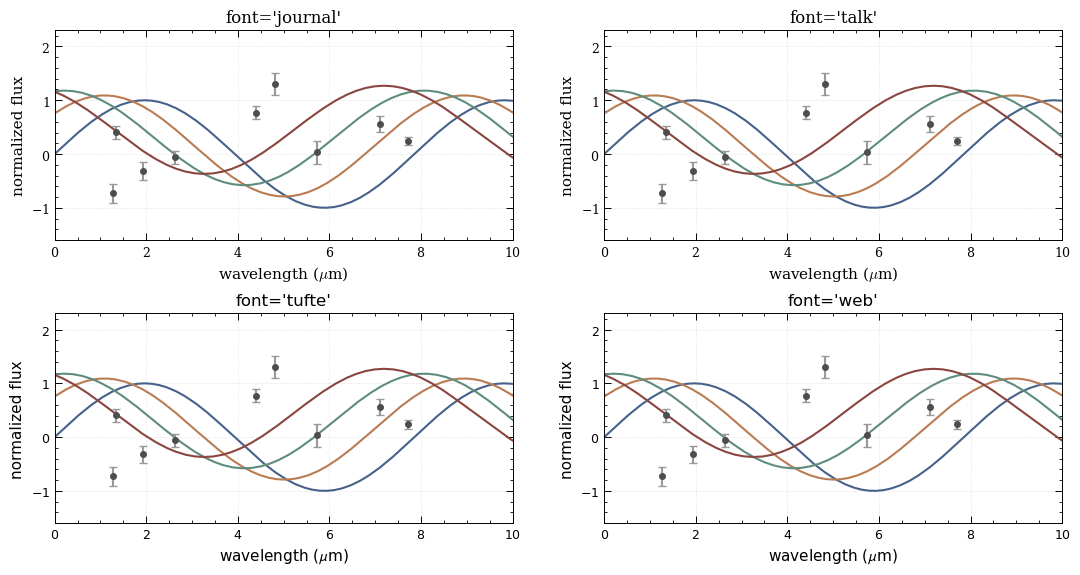

In [19]:
fig = plt.figure(figsize=(13, 6.4))
for i, preset in enumerate(["journal", "talk", "tufte", "web"], start=1):
    with plt.style.context("default"), sph.style_context(base="standard",
                                                         font=preset):
        ax = fig.add_subplot(2, 2, i)
        demo_plot(ax, legend=False)
        ax.set_title(f"font='{preset}'", fontsize=12)
fig.subplots_adjust(wspace=0.2, hspace=0.35)
plt.show()

### A specimen catalog

To choose a face you have to *see* it. Each row below renders the identical line —
letterforms, an object designation, and numerals — in one typeface, grouped by
role, with its tier noted. (These are real renders: what you see is what your
figure gets, where the face is installed.)

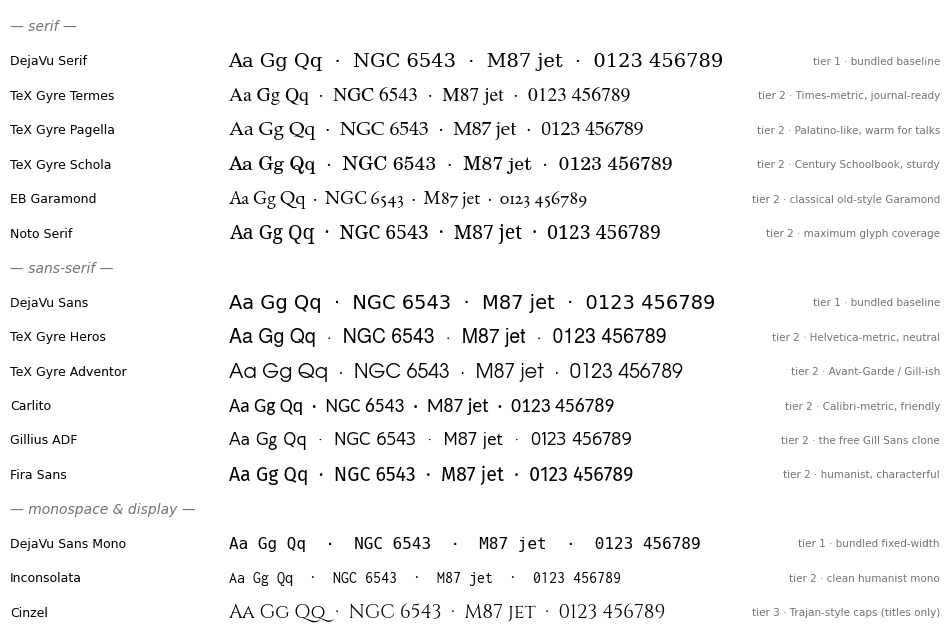

In [20]:
SAMPLE = "Aa Gg Qq  ·  NGC 6543  ·  M87 jet  ·  0123 456789"
GENERIC_FALLBACK = {"serif": "DejaVu Serif", "sans-serif": "DejaVu Sans",
                    "monospace": "DejaVu Sans Mono"}

# (face, generic, tier, note) grouped by category.
CATALOG = [
    ("— serif —", None, None, None),
    ("DejaVu Serif", "serif", "1", "bundled baseline"),
    ("TeX Gyre Termes", "serif", "2", "Times-metric, journal-ready"),
    ("TeX Gyre Pagella", "serif", "2", "Palatino-like, warm for talks"),
    ("TeX Gyre Schola", "serif", "2", "Century Schoolbook, sturdy"),
    ("EB Garamond", "serif", "2", "classical old-style Garamond"),
    ("Noto Serif", "serif", "2", "maximum glyph coverage"),
    ("— sans-serif —", None, None, None),
    ("DejaVu Sans", "sans-serif", "1", "bundled baseline"),
    ("TeX Gyre Heros", "sans-serif", "2", "Helvetica-metric, neutral"),
    ("TeX Gyre Adventor", "sans-serif", "2", "Avant-Garde / Gill-ish"),
    ("Carlito", "sans-serif", "2", "Calibri-metric, friendly"),
    ("Gillius ADF", "sans-serif", "2", "the free Gill Sans clone"),
    ("Fira Sans", "sans-serif", "2", "humanist, characterful"),
    ("— monospace & display —", None, None, None),
    ("DejaVu Sans Mono", "monospace", "1", "bundled fixed-width"),
    ("Inconsolata", "monospace", "2", "clean humanist mono"),
    ("Cinzel", "serif", "3", "Trajan-style caps (titles only)"),
]

fig, ax = plt.subplots(figsize=(12, 0.42 * len(CATALOG) + 0.5))
n = len(CATALOG)
for r, (face, generic, tier, note) in enumerate(CATALOG):
    y = n - 1 - r
    if generic is None:                                  # a category header row
        ax.text(0.0, y, face, fontsize=10, va="center", style="italic",
                family="DejaVu Sans", color="0.45")
        continue
    ok = face in _AVAIL
    stack = [face, GENERIC_FALLBACK[generic]]
    flag = "" if ok else "  (fallback)"
    ax.text(0.0, y, face + flag, fontsize=9, va="center", family="DejaVu Sans")
    # Monospace glyphs run much wider — drop their sample a size so it clears
    # the note column.
    fs = 11.5 if generic == "monospace" else 14
    ax.text(0.235, y, SAMPLE, family=stack, fontsize=fs, va="center")
    ax.text(1.0, y, f"tier {tier} · {note}", fontsize=7.5, va="center",
            ha="right", family="DejaVu Sans", color="0.45")
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, n - 0.5)
ax.axis("off")
plt.show()

### Why a stack, not a single font

Here is the rule in action. Suppose the elegant serif you designed your figure
around isn't installed on the machine that renders it. Ask for it as a *single*
family (left) and matplotlib silently substitutes its default sans — the figure
loses the look entirely, and the only trace is a `findfont` message that's easy
to miss. Ask for it at the head of a *stack* (right) and matplotlib walks past
the missing face to your next choice — here a Palatino-style serif — so the
figure keeps the character you intended:

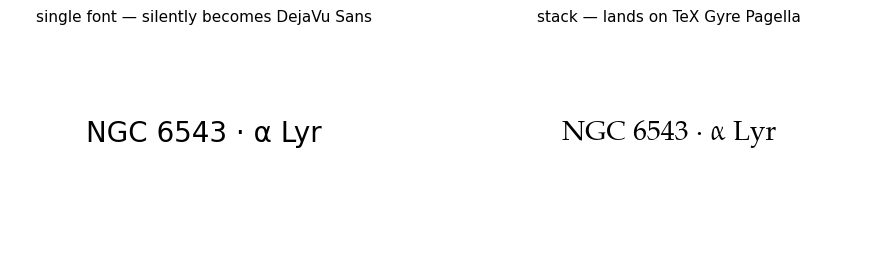

In [21]:
missing = "My Favorite Serif"        # pretend this face isn't installed (it isn't)
fig = plt.figure(figsize=(11, 3.0))

ax = fig.add_subplot(1, 2, 1)
ax.text(0.5, 0.55, "NGC 6543 · α Lyr", ha="center", va="center",
        family=[missing], fontsize=20)
ax.set_title("single font — silently becomes DejaVu Sans", fontsize=11)
ax.axis("off")

ax = fig.add_subplot(1, 2, 2)
ax.text(0.5, 0.55, "NGC 6543 · α Lyr", ha="center", va="center",
        family=[missing, "TeX Gyre Pagella", "DejaVu Serif"], fontsize=20)
ax.set_title("stack — lands on TeX Gyre Pagella", fontsize=11)
ax.axis("off")
plt.show()

> **Important — a stack falls back per *family*, not per *glyph*.** matplotlib
> picks **one** family for a whole string: it walks the stack until it finds an
> *installed* face, then sets every character in that face. If the face it lands
> on is missing a particular character, you get a "tofu" box — and the rest of
> the stack does **not** rescue it. This matters for sky figures because
> sexagesimal labels use the prime marks `′ ″`, which a surprising number of
> otherwise-excellent faces omit. `set_font` helps by *checking*: when the face a
> preset resolves to can't carry the prime marks, it emits a warning that names
> the problem and points to fixes — a prime-carrying face, or a letter-style
> separator like `dms_letter` (see [Decorating Frames](decorating_frames.ipynb)).
> It leaves your chosen face in place, so the warning is your cue to act rather
> than a silent swap. Two common faces it catches are `journal`'s Termes and
> `web`'s Heros — both gorgeous, both prime-less. (Set `font.family` by hand and
> you don't even get the warning, so put a prime-carrying face first.)

### Pairing the math font

Sky figures are full of `$\alpha$`, `$\delta$`, degree symbols, and exponents, so
the *math* font matters independently of the text font. `set_font` pairs them for
you (`math='auto'`): a serif body gets Computer Modern (`cm`), a sans body gets
`stixsans`. The same math-heavy labels under each pairing — notice how the math
harmonizes with the surrounding text rather than clashing:

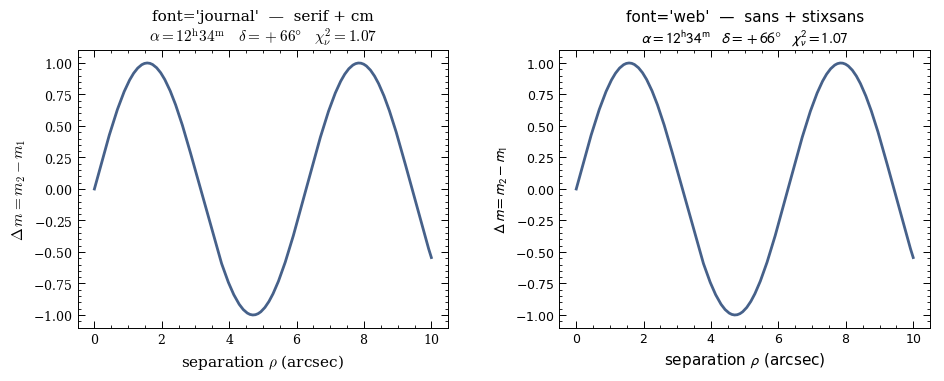

In [22]:
fig = plt.figure(figsize=(11, 3.6))
pairs = [("journal", "serif + cm"), ("web", "sans + stixsans")]
for i, (preset, desc) in enumerate(pairs, start=1):
    with plt.style.context("default"), sph.style_context(base="standard",
                                                         font=preset):
        ax = fig.add_subplot(1, 2, i)
        ax.plot(_x, np.sin(_x), lw=2)
        ax.set_xlabel(r"separation $\rho$ (arcsec)")
        ax.set_ylabel(r"$\Delta\,m = m_2 - m_1$")
        ax.set_title(rf"font='{preset}'  —  {desc}" + "\n"
                     r"$\alpha=12^{\rm h}34^{\rm m}\quad\delta=+66\degree\quad"
                     r"\chi^2_\nu=1.07$", fontsize=11)
fig.subplots_adjust(wspace=0.3)
plt.show()

### Platform reality-check

The same "look" lives under different names on each OS, and almost none are
universal — which is why a stack that ends in a portable face is essential. A few
the field hits often:

| The look you want | macOS | Windows | Linux | Portable stack to use |
| --- | --- | --- | --- | --- |
| Calibri-style humanist sans | (absent) | Calibri | (absent) | `['Calibri', 'Carlito', 'DejaVu Sans']` |
| Cambria-style serif | (absent) | Cambria | (absent) | `['Cambria', 'Caladea', 'DejaVu Serif']` |
| Gill Sans humanist sans | Gill Sans | (Adobe) | (absent) | `['Gill Sans', 'Gillius ADF', 'TeX Gyre Adventor', 'DejaVu Sans']` |
| Trajan monumental caps | (absent) | (Adobe) | (absent) | `['Trajan Pro', 'Cinzel', 'TeX Gyre Bonum']` |

The lesson is always the same: **lead with the prettiest target, end with a
guaranteed face.** `set_font` builds exactly this shape from a preset or a single
face name.

### Suggested text + math pairings

A few combinations that reliably read well:

| Use | Text | Math |
| --- | --- | --- |
| Journal / publication | TeX Gyre Termes (`font='journal'`) | `cm` |
| Talk / poster (warm) | TeX Gyre Pagella (`font='talk'`) | `cm` |
| Tufte / vintage chart | TeX Gyre Adventor (`font='tufte'`) | `stixsans` |
| Web / docs (modern) | TeX Gyre Heros (`font='web'`) | `stixsans` |
| Maximum safety | DejaVu Serif (`font='serif'`) | `dejavuserif` |

### Fixed-width text — `MONO_STACK`

One more font tool: `sph.MONO_STACK`, a ready monospace family list for any text
artist where columns must line up — an on-plot fit-results box, or fixed-width
coordinate readouts where proportional digits would jitter. Hand it to
`family=`:

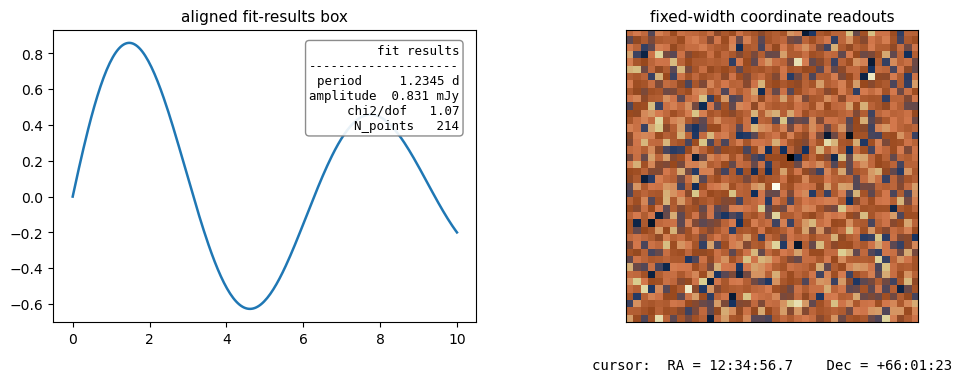

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# Left: an aligned fit-results box (monospace keeps the columns straight).
ax = axes[0]
ax.plot(_x, np.sin(_x) * np.exp(-_x * 0.1), lw=1.8)
ax.set_title("aligned fit-results box", fontsize=11)
results = ("fit results\n"
          "--------------------\n"
          "period     1.2345 d\n"
          "amplitude  0.831 mJy\n"
          "chi2/dof   1.07\n"
          "N_points   214")
# The box matches the axes background, so the panel works on a light or dark page.
ax.text(0.96, 0.95, results, transform=ax.transAxes, ha="right", va="top",
        family=sph.MONO_STACK, fontsize=9,
        bbox=dict(boxstyle="round", fc=ax.get_facecolor(), ec="0.5", alpha=0.9))

# Right: fixed-width coordinate readouts that don't jitter as the digits change
# (shown on one of the bundled image colormaps from Section 4).
ax = axes[1]
ax.imshow(np.random.default_rng(1).normal(0, 1, (40, 40)), cmap="sph.deepsky")
ax.set_title("fixed-width coordinate readouts", fontsize=11)
ax.text(0.5, -0.16, "cursor:  RA = 12:34:56.7    Dec = +66:01:23",
        transform=ax.transAxes, ha="center", family=sph.MONO_STACK, fontsize=10)
ax.set_xticks([])
ax.set_yticks([])
fig.subplots_adjust(wspace=0.2)
plt.show()

### A hand-drawn closer

For an informal explainer — "here's the idea before we make it rigorous" — a
handwriting font plus matplotlib's sketch filter is delightful. `font='sketch'`
sets the hand-drawn family stack, and `plt.xkcd()` adds the wobbly, hand-inked
*lines* that complete the effect. (The faces are tier-3, registered above; on a
machine without them the text simply falls back.)

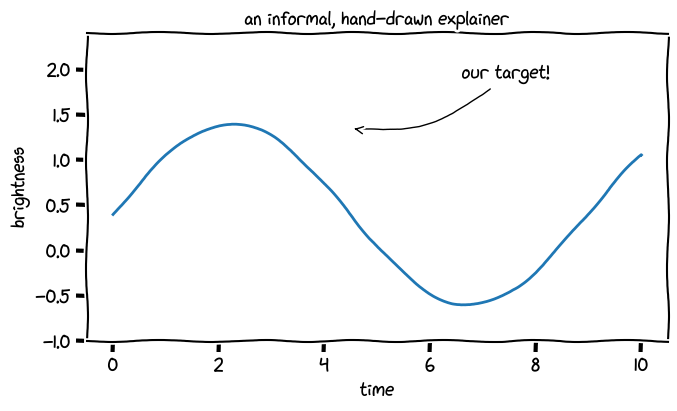

In [24]:
# plt.xkcd() is itself a style context — it restores everything on exit, so the
# set_font inside stays contained to this figure.
with plt.xkcd(scale=1.0, length=120, randomness=3):
    sph.set_font("sketch")                # hand-drawn family on top of the sketch lines
    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    ax.plot(_x, np.sin(_x * 0.7) + 0.4, lw=2)
    ax.annotate("our target!", xy=(4.5, 1.35), xytext=(6.6, 1.9),
                fontsize=14,
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.25"))
    ax.set_xlabel("time")
    ax.set_ylabel("brightness")
    ax.set_title("an informal, hand-drawn explainer", fontsize=14)
    ax.set_ylim(-1, 2.4)
    plt.show()

> **Note:** the handwriting faces are deliberately opt-in (`font='sketch'`), never
> a default, and some are missing the prime/middot glyphs sky labels use — so keep
> a `DejaVu Sans` fallback in the stack (`set_font` does) and reserve the sketch
> look for explainer figures, not finished science plots.

## 7. Styling sky frames

One detail is specific to sky plotting. A `WCSAxes` — the frame behind every
all-sky map, globe, and tangent field — draws its own ticks and labels through
astropy's `ax.coords` machinery, which doesn't read matplotlib's `xtick.*`/
`ytick.*` rcParams the way ordinary axes do. The good news: skyplothelper makes
its frames **theme-aware at build time**, so a frame *built under a theme* picks
up the theme's foreground automatically — the common path just works. Here the
left frame is built inside a dark context with **no extra styling call**, and its
ticks and labels already read:

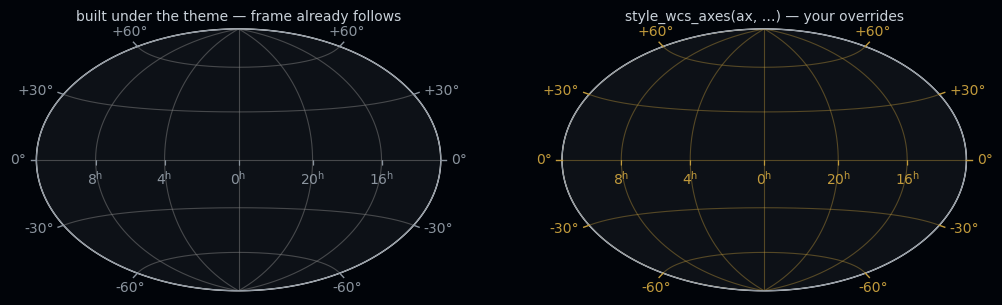

In [25]:
with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(12, 3.4))   # built inside the context so the page is dark
    # Left: built under the theme — ticks/labels already follow, no extra call.
    ax = sph.make_wcs_frame(121, "AIT", center=0, frame="ICRS", fig=fig)
    ax.set_title("built under the theme — frame already follows", fontsize=10)
    # Right: the same frame, with style_wcs_axes used to OVERRIDE — recolor the
    # ticks/labels and the graticule to an accent for emphasis (a warm gold pulled
    # from the uranometria cycle, so it reads on either page).
    gold = sph.CYCLE_PALETTES["uranometria"]["colors"][2]
    ax = sph.make_wcs_frame(122, "AIT", center=0, frame="ICRS", fig=fig)
    sph.style_wcs_axes(ax, tick_color=gold, labelcolor=gold,
                       grid=True, grid_color=gold, grid_alpha=0.4)
    ax.set_title("style_wcs_axes(ax, …) — your overrides", fontsize=10)
    fig.subplots_adjust(wspace=0.3)
    plt.show()

So you rarely *need* `style_wcs_axes` just to follow a theme. It earns its keep
in two situations:

- **Retrofitting a theme** onto a frame built *before* you set it. Switching the
  session theme — `sph.set_theme("dark_sky")` — recolors *new* artists, but a
  frame already drawn keeps its old tick/label colors. One call brings it up to
  date: `sph.style_wcs_axes(ax)` carries the *currently active* theme onto an
  existing frame.
- **Overriding** the frame's look for emphasis (right panel above): it takes
  `tick_color`, `labelcolor`, `major_size`/`minor_size`, `labelsize`,
  `frame_color`, `direction`, and grid keywords. Its companion
  **`style_grid(ax, …)`** tunes just the graticule (`color`, `alpha`, `lw`,
  `ls`) — handy for muting a primary grid under an overlay.

You can also set the graticule up **at build time**: every frame builder
(`make_wcs_frame`, `make_globe_frame`, `make_cone_frame`, …) takes `grid=`,
`gridcolor=`, `gridalpha=`, and — newly — `gridlw=` and `gridls=` for line width
and style. Same result as a follow-up `style_grid` call, one step earlier:

```python
ax = sph.make_wcs_frame(111, "AIT", center=0, grid=True,
                        gridcolor="0.6", gridlw=0.6, gridls=":")
```

> **Tip — dark mode for your own sky figures.** Wrap the build in
> `with sph.style_context(theme="dark_sky", palette="nightcap"):` and the frame,
> page, and data colors all come out dark together — no follow-up call needed.
> (Reach for `style_wcs_axes` only if you flip the theme *after* building, or
> want to override.) Saving works as expected too: `savefig` inherits the dark
> figure background, so the file keeps its dark page. The light/dark toggle on
> these docs pages is driven by exactly this — every figure is re-rendered under
> a dark theme.

> **Note:** `style_wcs_axes` is about *theme* color/size. The frame's tick
> *formats, placement, minor ticks, and label rotation* are a different topic,
> covered in [Decorating Frames](decorating_frames.ipynb).

## 8. Building a house style

The payoff of a layered system is a **house style** — one coherent identity you
apply to everything, so a light curve, an all-sky map, and a finder chart all look
like they belong to the same project. Define it once (mixing presets with your own
touches — here a custom five-color cycle), then wear it everywhere:

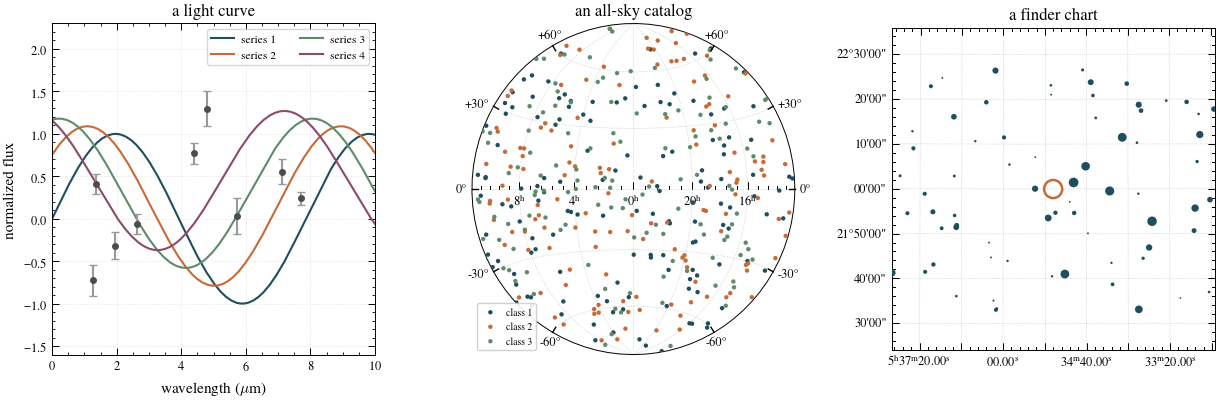

In [26]:
# Your house style, defined once. Mix bundled presets with your own choices —
# here a custom data-color cycle passed straight to the palette layer.
MY_COLORS = ["#1F4E5F", "#C56B39", "#5E8C6A", "#8A4B6B", "#B7A23B"]
HOUSE = dict(base="standard", palette=MY_COLORS, font="journal")

rng = np.random.default_rng(8)
n_sky = 400
sky_ra = rng.uniform(0, 360, n_sky)
sky_dec = np.degrees(np.arcsin(rng.uniform(-1, 1, n_sky)))   # uniform on the sphere
sky_pop = rng.integers(0, 3, n_sky)                          # three "populations"

with plt.style.context("default"), sph.style_context(**HOUSE):
    fig = plt.figure(figsize=(15, 4.3))

    # (1) a light curve / series plot — ordinary axes.
    ax = fig.add_subplot(1, 3, 1)
    demo_plot(ax)
    ax.set_title("a light curve")

    # (2) an all-sky scatter — three populations cycle through the house colors.
    ax = sph.make_wcs_frame((1, 3, 2), "AIT", center=0, frame="ICRS", fig=fig)
    sph.style_wcs_axes(ax)
    tr = ax.get_transform("world")
    for p in range(3):
        m = sky_pop == p
        ax.scatter(sky_ra[m], sky_dec[m], transform=tr, s=10,
                   color=MY_COLORS[p], edgecolors="none", label=f"class {p + 1}")
    ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
    ax.set_title("an all-sky catalog")

    # (3) a finder chart — same colors, on a zoomed field.
    ax = sph.make_wcs_frame((1, 3, 3), "TAN", center=FCEN, fov_deg=1.2, fig=fig)
    sph.style_wcs_axes(ax)
    tr = ax.get_transform("world")
    ax.scatter(fra, fdec, transform=tr, s=fsz, color=MY_COLORS[0],
               edgecolors="none")
    ax.scatter([FCEN[0]], [FCEN[1]], transform=tr, s=170, facecolors="none",
               edgecolors=MY_COLORS[1], linewidths=1.8)
    ax.set_title("a finder chart")
    fig.subplots_adjust(wspace=0.3)
    plt.show()

One palette, one font, one structure — three very different figures that
unmistakably belong together. And because the layers are independent, **retargeting
the same content for a different venue is a one-line change**: the same plot as a
light paper figure, a bold talk slide, and a dark web post:

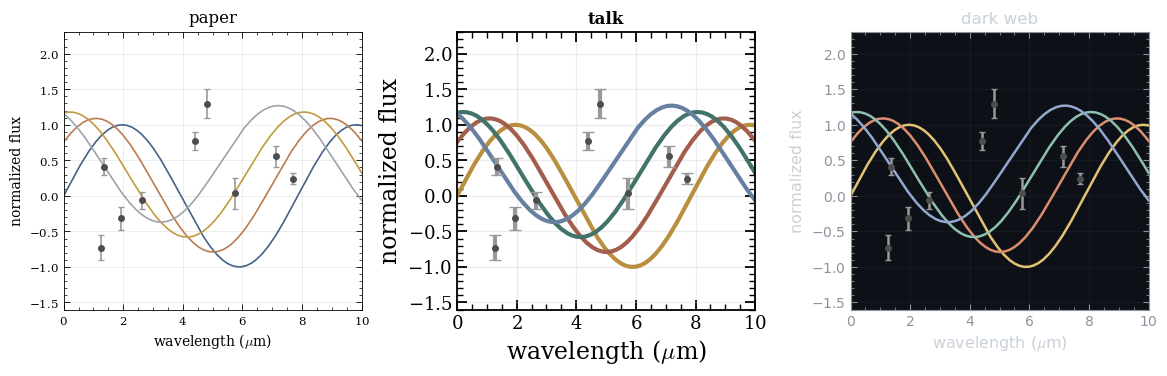

In [27]:
recipes = [
    ("paper", dict(base="journal", palette="uranometria", font="journal")),
    ("talk", dict(base="poster", palette="speakeasy", font="talk")),
    ("dark web", dict(base="screen", theme="dark_sky", palette="nightcap",
                      font="web")),
]
fig = plt.figure(figsize=(14, 3.6))
for i, (label, recipe) in enumerate(recipes, start=1):
    with plt.style.context("default"), sph.style_context(**recipe):
        ax = fig.add_subplot(1, 3, i)
        demo_plot(ax, legend=False)
        ax.set_title(label, fontsize=12)
fig.subplots_adjust(wspace=0.32)
plt.show()

Same data, same code, three audiences — each a single recipe swap. That is the
whole point of a composable style system: decide your look once, then spend zero
further effort making every figure wear it.

## 9. Quick reference

The whole system on one screen — pick a layer, pick a preset:

| Layer | Setter / keyword | Presets |
| --- | --- | --- |
| **base** (structure) | `set_base_style` / `base=` | `standard`, `structural`, `journal`, `press`, `poster`, `tufte`, `screen`, `minimalist`\* |
| **theme** (page) | `set_theme` / `theme=` | `publication`, `twilight`, `dark_sky`, `poster` (+ any matplotlib built-in) |
| **palette** (data colors) | `set_palette` / `palette=` | `speakeasy`, `atlas`, `uranometria` (dual); `letterpress` (light); `nightcap`, `velvet` (dark) |
| **font** (typeface + math) | `set_font` / `font=` | `journal`, `talk`/`poster`, `tufte`, `web`, `classical`, `sketch`, `mono` |
| **annotation** (sky scaffolding) | `style_annotation(ax, …)` | `parchment`, `publication` (light); `dark`, `night`, `denim` (dark) |
| **sky frames** (carry/override) | `style_wcs_axes(ax, …)`, `style_grid(ax, …)` | — |

\* `minimalist` is for splash/title images and purely qualitative plots — not
figures whose reader must read values off the axes.

Apply any combination at once with `sph.set_style(base=…, theme=…, palette=…,
font=…)` (persistent) or `with sph.style_context(…):` (temporary), composed in the
order **base → theme → palette → font → your rcParams**. Every registry is a live
dict you can iterate — `BASE_PRESETS`, `CYCLE_PALETTES`, `ANNOTATION_PALETTES`,
`FONT_PRESETS` — so your own galleries stay in sync as presets are added.

**Resetting.** To get back to stock matplotlib mid-session, `sph.set_base_style(
"default")` restores *all* the rcParams defaults (structure, colors, and fonts —
it calls `plt.rcdefaults()` under the hood), and `sph.set_font("default")` resets
just the font family and math fontset.

### A decision guide

| Your situation | A good starting recipe |
| --- | --- |
| Churning out plots to *inspect* data | `set_style(base="structural")` — better defaults, your colors kept |
| Writing a **paper** | `set_style(base="journal", palette="uranometria", font="journal")` |
| A **talk** or **poster** | `set_style(base="poster", palette="speakeasy", font="talk")` |
| A figure for the **web / docs** | `set_style(base="screen", font="web")` |
| A **dark slide or web** figure | `set_style(base="screen", theme="dark_sky", palette="nightcap")` — set it *before* building, and sky frames follow automatically |
| A **finder chart** | build the frame, then `style_annotation(ax, "publication")` (or `"night"` for dark) |
| A **splash / title** image or a purely **qualitative** slide | `set_style(base="minimalist")` — frameless; great when no one reads values off the axes |

Treat these as starting points: every layer is independent, so adjust one without
disturbing the rest, and pass any extra `rcParams` last for the finishing touches.

## 10. Where to go next

This tutorial covered the *whole-figure* look. The natural next steps:

| If you want to… | Go to |
| --- | --- |
| style a frame's **own** ticks, gridlines, and labels (formats, placement, rotation) | [Decorating Frames](decorating_frames.ipynb) |
| the dense **reference** for every preset and palette | [Styling & themes guide](../guide/styling.md) |
| put data on a frame and learn the conventions | [Getting Started](getting_started.ipynb) |
| choose a projection / frame type for your map | [A Tour of Projections](projections.ipynb) |
| draw a second coordinate grid over a frame | [Overlay Coordinate Grids](overlay_grids.ipynb) |
| apply a bundled **image colormap** to a FITS raster (stretches, colorbars) | [FITS Images & Quicklook](fits_images.ipynb) |
| the finder-chart overlays themselves (compass, scale bars, reticles) | [Annotations & Overlays](annotations.ipynb) |

With base, theme, palette, font, and the sky-frame helpers in hand, every figure
in the rest of the series can wear your house style — exactly the move
[Building a house style](#8.-Building-a-house-style) put together. Enjoy making
everything you plot look like yours.